# 05b - Feature Reduction Study
**Supplement to notebook 04, Part B (selecting the crash fields)**

The benchmark crash models use 1,317 features (1,410 columns once coded fields are one-hot encoded). Evaluating them raised two fair questions:
1. **Are all of these features needed?**
2. **Which technique should reduce them, and what is lost?**

This study compares the main families of feature reduction on the real crash data, for both crash models (S1 injury, S2 serious or fatal), starting from the benchmark. Its result, that **permutation-importance ranking** is the best technique, is why notebook 04 uses that technique in Step 3 of the field selection. The full analysis is in `feature_reduction.py`; this notebook loads and explains its results.

| Family | Idea | Techniques tested |
|---|---|---|
| **Filter** | Score columns on their own, before modelling | Near-constant removal; correlation pruning; mutual-information ranking |
| **Embedded** | The model itself selects or down-weights features | L1 (Lasso) logistic regression; permutation-importance ranking from the selected model |
| **Dimensionality reduction** | Combine many columns into a few new ones | Principal Component Analysis (PCA) |

**Rules (same as the main project):** every ranking, filter and PCA is fitted on **training years 2020-2022 only**; techniques are compared on **validation 2023**; **test 2024** is reported for reference. Every reduced set is scored with the same Gradient Boosting configuration as the benchmark model; PCA and L1 are also scored with Logistic Regression.

## 5b.0 Setup

In [1]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import Image, display

HERE = Path.cwd().resolve()
ROOT = HERE.parent if HERE.name in ("feature_reduction", "notebooks") else HERE
RESULTS = ROOT / "feature_reduction" / "results"
pd.set_option("display.max_columns", 20, "display.width", 200, "display.precision", 4)
res = pd.read_csv(RESULTS / "all_results.csv")
notes = {t: json.loads((RESULTS / f"{t}_notes.json").read_text()) for t in ("y_injury", "y_serious")}
full = res[res.method == "All features"].set_index("target")
res["share_of_full_val_pr_auc"] = res.validation_pr_auc / res.target.map(full.validation_pr_auc)
show = lambda d: d[["method", "n_features", "model", "validation_pr_auc", "share_of_full_val_pr_auc", "test_roc_auc", "test_pr_auc"]].round(4)

## 5b.1 Reference: all features
The starting point is the benchmark model from notebook 04 (Part A): Gradient Boosting on all 1,410 encoded columns.

In [2]:
show(res[res.method == 'All features'].assign(method=lambda d: d.target + ' | ' + d.method))

,method,n_features,model,validation_pr_auc,share_of_full_val_pr_auc,test_roc_auc,test_pr_auc
0,y_injury | All features,1410,Gradient Boosting,0.9190,1.0,0.9063,0.9185
32,y_serious | All features,1410,Gradient Boosting,0.6471,1.0,0.9017,0.6421


**Interpretation.** S1 reaches validation PR-AUC 0.919 and S2 0.647; these are the 100% marks the reduced sets are compared against.

## 5b.2 Filter methods: near-constant and highly correlated columns
* **Near-constant:** a column that is non-zero in fewer than 0.1% of training crashes (a code almost nobody has) carries almost no information.
* **Correlation pruning:** if two columns move almost identically (correlation above 0.95), one of them is redundant. Columns are kept in order, and any column that correlates above 0.95 with one already kept is dropped (computed on a 40,000-crash training sample).

In [3]:
display(pd.DataFrame({t: {k: v for k, v in n.items() if k in ("encoded_columns", "near_constant_removed",
                                                             "correlated_removed_after_near_constant")}
                      for t, n in notes.items()}))
show(res[res.method.isin(["Near-constant removed", "Correlation pruned (|r|>0.95)"])].assign(method=lambda d: d.target + " | " + d.method))

,y_injury,y_serious
near_constant_removed,160,160
correlated_removed_after_near_constant,174,175
encoded_columns,1410,1410


,method,n_features,model,validation_pr_auc,share_of_full_val_pr_auc,test_roc_auc,test_pr_auc
1,y_injury | Near-constant removed,1250,Gradient Boosting,0.9191,1.0001,0.9062,0.9185
2,y_injury | Correlation pruned (|r|>0.95),1076,Gradient Boosting,0.9186,0.9995,0.9063,0.9185
33,y_serious | Near-constant removed,1250,Gradient Boosting,0.6481,1.0014,0.9013,0.6411
34,y_serious | Correlation pruned (|r|>0.95),1075,Gradient Boosting,0.6465,0.9989,0.9015,0.6409


**Interpretation.** Simple filters remove **about a quarter of the columns** (335 of 1,410): 160 near-constant, then about 175 highly correlated, leaving about 1,075. They lose **no** performance (S1 0.919 → 0.919; S2 0.647 → 0.647). Much of the width is redundancy, which the model already handles.

## 5b.3 Filter method: mutual-information ranking
**Mutual information** measures how much knowing a column's value reduces uncertainty about the outcome, on its own, without a model. Columns are ranked by it and only the top *k* are kept.

In [4]:
for t in ("y_injury", "y_serious"):
    print(t); display(show(res[(res.target == t) & (res.method == "Mutual information top-k")]))

y_injury


,method,n_features,model,validation_pr_auc,share_of_full_val_pr_auc,test_roc_auc,test_pr_auc
3,Mutual information top-k,10,Gradient Boosting,0.7705,0.8384,0.7774,0.7644
4,Mutual information top-k,25,Gradient Boosting,0.8800,0.9575,0.8595,0.8787
5,Mutual information top-k,50,Gradient Boosting,0.8994,0.9787,0.8791,0.8984
6,Mutual information top-k,100,Gradient Boosting,0.9064,0.9863,0.8901,0.9058
7,Mutual information top-k,200,Gradient Boosting,0.9136,0.9942,0.8989,0.9124
8,Mutual information top-k,400,Gradient Boosting,0.9169,0.9978,0.9037,0.9161


y_serious


,method,n_features,model,validation_pr_auc,share_of_full_val_pr_auc,test_roc_auc,test_pr_auc
35,Mutual information top-k,10,Gradient Boosting,0.4783,0.7392,0.8360,0.4638
36,Mutual information top-k,25,Gradient Boosting,0.5138,0.7939,0.8515,0.5009
37,Mutual information top-k,50,Gradient Boosting,0.5364,0.8288,0.8619,0.5293
38,Mutual information top-k,100,Gradient Boosting,0.5925,0.9155,0.8868,0.5897
39,Mutual information top-k,200,Gradient Boosting,0.6164,0.9525,0.8932,0.6104
40,Mutual information top-k,400,Gradient Boosting,0.6333,0.9786,0.8986,0.6306


**Interpretation.** Ranking columns one at a time works, but slowly: S1 needs about 200 columns for 99% of full performance; S2 reaches only about 98% even with 400. Mutual information favours columns that are informative **on their own** (many of its top picks describe pedestrians: ages, counts, locations), so it keeps overlapping information and misses columns that matter only in **combination**.

## 5b.4 Embedded method: permutation-importance ranking
Columns are ranked by **permutation importance** from the benchmark model: how much validation performance drops when a column's values are shuffled. This reflects what the model actually uses, including combinations. The top *k* are kept and the model retrained.

In [5]:
for t in ("y_injury", "y_serious"):
    print(t); display(show(res[(res.target == t) & (res.method == "Permutation importance top-k")]))

y_injury


,method,n_features,model,validation_pr_auc,share_of_full_val_pr_auc,test_roc_auc,test_pr_auc
9,Permutation importance top-k,10,Gradient Boosting,0.8879,0.9662,0.8635,0.8855
10,Permutation importance top-k,25,Gradient Boosting,0.9079,0.9879,0.8927,0.9072
11,Permutation importance top-k,50,Gradient Boosting,0.9155,0.9962,0.9013,0.9143
12,Permutation importance top-k,100,Gradient Boosting,0.9183,0.9992,0.9049,0.9171
13,Permutation importance top-k,200,Gradient Boosting,0.9190,0.9999,0.9057,0.9179
14,Permutation importance top-k,400,Gradient Boosting,0.9192,1.0002,0.9061,0.9183


y_serious


,method,n_features,model,validation_pr_auc,share_of_full_val_pr_auc,test_roc_auc,test_pr_auc
41,Permutation importance top-k,10,Gradient Boosting,0.5142,0.7946,0.8526,0.5006
42,Permutation importance top-k,25,Gradient Boosting,0.5496,0.8493,0.8679,0.5414
43,Permutation importance top-k,50,Gradient Boosting,0.6109,0.9440,0.8893,0.6014
44,Permutation importance top-k,100,Gradient Boosting,0.6385,0.9867,0.9003,0.6369
45,Permutation importance top-k,200,Gradient Boosting,0.6461,0.9984,0.9000,0.6371
46,Permutation importance top-k,400,Gradient Boosting,0.6478,1.0009,0.9011,0.6391


**Interpretation.** This is the most efficient technique by far:
* **S1:** 10 columns give 97% of full performance, **50 give 99.6%**, 100 give 99.9%.
* **S2:** 100 columns give 98.7%, **200 give 99.8%**; the rarer, harder outcome needs a few more.

The test year confirms it is not a validation artefact: with 100 columns, test ROC-AUC is 0.905 (S1) and 0.900 (S2), against 0.906 and 0.902 with all columns. (The ranking itself came from validation data, which is why the untouched test scores are the fair check; they were not used to choose anything.)

## 5b.5 Embedded method: L1 (Lasso) logistic regression
L1 regularisation adds a penalty that pushes weak coefficients to **exactly zero**, so the model selects features while it trains. A smaller `C` means a stronger penalty and fewer features kept.

In [6]:
for t in ("y_injury", "y_serious"):
    print(t); display(show(res[(res.target == t) & res.method.str.startswith("L1")]))

y_injury


,method,n_features,model,validation_pr_auc,share_of_full_val_pr_auc,test_roc_auc,test_pr_auc
15,L1 logistic (C=0.0002),24,Logistic Regression,0.8910,0.9695,0.8708,0.8895
16,L1 logistic (C=0.0005),46,Logistic Regression,0.9016,0.9811,0.8867,0.9002
17,L1 logistic (C=0.001),81,Logistic Regression,0.9060,0.9858,0.8927,0.9046
18,L1 logistic (C=0.003),229,Logistic Regression,0.9095,0.9897,0.8967,0.9086
19,L1 logistic (C=0.01),559,Logistic Regression,0.9106,0.9908,0.8970,0.9098
20,L1 logistic (C=0.05),969,Logistic Regression,0.9105,0.9907,0.8917,0.9035
21,L1-selected (C=0.01) then GB,559,Gradient Boosting,0.9184,0.9993,0.9056,0.9178


y_serious


,method,n_features,model,validation_pr_auc,share_of_full_val_pr_auc,test_roc_auc,test_pr_auc
47,L1 logistic (C=0.0002),15,Logistic Regression,0.4819,0.7446,0.8374,0.4678
48,L1 logistic (C=0.0005),47,Logistic Regression,0.5448,0.8419,0.8643,0.5292
49,L1 logistic (C=0.001),81,Logistic Regression,0.5700,0.8808,0.8751,0.5557
50,L1 logistic (C=0.003),205,Logistic Regression,0.5915,0.9140,0.8833,0.5803
51,L1 logistic (C=0.01),554,Logistic Regression,0.5954,0.9201,0.8843,0.5857
52,L1 logistic (C=0.05),992,Logistic Regression,0.5710,0.8824,0.8734,0.5598
53,L1-selected (C=0.01) then GB,554,Gradient Boosting,0.6445,0.9959,0.9000,0.6379


**Interpretation.** With 81 features, L1 logistic regression reaches 98.6% of the full model for S1 but only 88% for S2. As a *linear* model it can't capture interactions, so it plateaus below Gradient Boosting whatever the number of features. Using the features L1 selects (about 555) inside Gradient Boosting recovers almost all performance, but with far more features than the importance ranking needs.

## 5b.6 Dimensionality reduction: PCA
**Principal Component Analysis** replaces the original columns with a smaller number of new "components", each a weighted mix of **all** the original columns, chosen to keep as much of the data's variation as possible. Components are fitted on standardised training data.

In [7]:
display(pd.DataFrame({t: n["pca_variance_explained"] for t, n in notes.items()}).rename_axis("components").rename(columns=lambda c: f"{c}: share of variance kept"))
for t in ("y_injury", "y_serious"):
    print(t); display(show(res[(res.target == t) & (res.method == "PCA components")]))

,y_injury: share of variance kept,y_serious: share of variance kept
components,,
10,0.181,0.179
25,0.264,0.261
50,0.349,0.343
100,0.461,0.455
200,0.595,0.591


y_injury


,method,n_features,model,validation_pr_auc,share_of_full_val_pr_auc,test_roc_auc,test_pr_auc
22,PCA components,10,Gradient Boosting,0.8711,0.9478,0.8465,0.8702
23,PCA components,10,Logistic Regression,0.8482,0.9230,0.8171,0.8488
24,PCA components,25,Gradient Boosting,0.8827,0.9605,0.8622,0.8820
25,PCA components,25,Logistic Regression,0.8726,0.9495,0.8491,0.8723
26,PCA components,50,Gradient Boosting,0.8851,0.9631,0.8658,0.8848
27,PCA components,50,Logistic Regression,0.8767,0.9539,0.8565,0.8775
28,PCA components,100,Gradient Boosting,0.8874,0.9656,0.8678,0.8867
29,PCA components,100,Logistic Regression,0.8817,0.9594,0.8616,0.8761
30,PCA components,200,Gradient Boosting,0.8880,0.9663,0.8685,0.8875
31,PCA components,200,Logistic Regression,0.8916,0.9702,0.8739,0.8858


y_serious


,method,n_features,model,validation_pr_auc,share_of_full_val_pr_auc,test_roc_auc,test_pr_auc
54,PCA components,10,Gradient Boosting,0.4437,0.6856,0.8245,0.4238
55,PCA components,10,Logistic Regression,0.3468,0.5359,0.7569,0.3370
56,PCA components,25,Gradient Boosting,0.4979,0.7694,0.8517,0.4829
57,PCA components,25,Logistic Regression,0.4625,0.7146,0.8382,0.4429
58,PCA components,50,Gradient Boosting,0.5052,0.7806,0.8539,0.4920
59,PCA components,50,Logistic Regression,0.4654,0.7191,0.8395,0.4455
60,PCA components,100,Gradient Boosting,0.5179,0.8002,0.8570,0.5052
61,PCA components,100,Logistic Regression,0.4904,0.7579,0.8489,0.4724
62,PCA components,200,Gradient Boosting,0.5163,0.7977,0.8503,0.4981
63,PCA components,200,Logistic Regression,0.2841,0.4390,0.7293,0.2747


**Interpretation.** PCA performs **worst**:
* Even 200 components keep only about **59% of the variation**: the crash features are genuinely diverse, not a few underlying factors.
* Its best results are about 97% of full performance for S1 and only about **80%** for S2. Variation in the inputs is not the same as information about the outcome, and rare serious-crash signals get diluted.
* It destroys **explainability**: a component such as "0.12 × pedestrians − 0.08 × airbag deployed + …" has no plain meaning, so the model could no longer say *why* a crash scores high. Keeping real, documented fields is a core principle of this project.

## 5b.7 All techniques compared
Validation PR-AUC against the number of features or components (log scale). The dotted line is the full model.

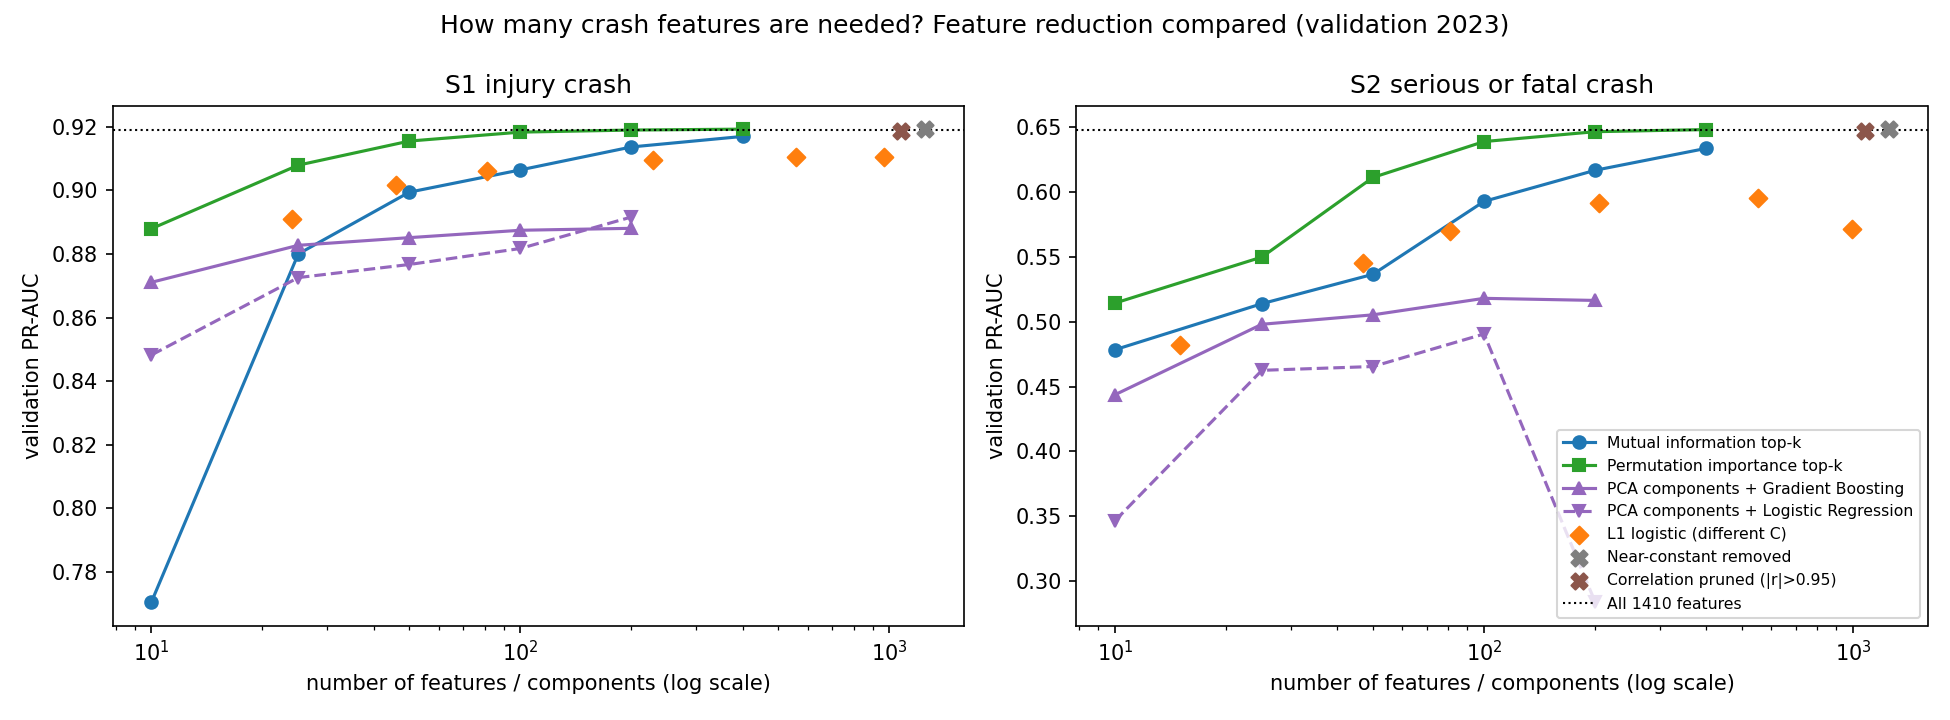

In [8]:
display(Image(filename=str(RESULTS / 'feature_reduction_comparison.png'), width=1000))

## 5b.8 How many features are needed?

In [9]:
summary = pd.read_csv(RESULTS / "features_needed_summary.csv")
summary.pivot_table(index=["target", "method"], columns="retain", values="features_needed", aggfunc="first")

retain                                  95% of full validation PR-AUC  99% of full validation PR-AUC
target    method                                                                                    
y_injury  Mutual information top-k                               25.0                          200.0
          PCA components                                         25.0                            NaN
          Permutation importance top-k                           10.0                           50.0
y_serious Mutual information top-k                              200.0                            NaN
          Permutation importance top-k                          100.0                          200.0

**Interpretation.** A blank means the technique never reached that level. To keep 99% of full performance, permutation importance needs **50 features (S1)** and **200 (S2)**; mutual information needs 200 for S1 and never gets there for S2; PCA never gets there.

## 5b.9 From this study to the final selection
This study ranks the benchmark's columns, including the VIN-decoded and post-crash fields. Notebook 04 applies the winning technique more strictly, in three steps:
1. **Ablation:** VIN-decoded fields removed (no validation gain).
2. **Post-crash fields removed** (recorded after the crash; mostly reflect the outcome), at a measured cost of about 0.01 ROC-AUC. The result is the **revised benchmark**.
3. **Permutation-importance ranking** of what remains, retraining on the top k features (a finer grid, starting at 5), and keeping the smallest k with at least **98% of the revised benchmark's validation PR-AUC**.

The finer grid is why the final models need fewer features than this study's 99% figures suggest: S1 meets the 98% rule at 15 features and S2 at 75.

In [10]:
SELECTION = ROOT / "outputs" / "selection"
sel = json.loads((SELECTION / "crss_selected_features.json").read_text())
rows = []
for t in ("y_injury", "y_serious"):
    d = pd.read_csv(SELECTION / f"crss_{t}_selection_topk.csv")
    k = sel[t]["k"]; r = d[d.k == k].iloc[0]
    rows.append({"target": t, "rule": "98% of revised benchmark (validation PR-AUC)", "k selected": k,
                 "raw fields": len(sel[t]["fields"]), "validation PR-AUC": r.validation_pr_auc,
                 "share of revised benchmark": r.share_of_benchmark_validation_pr_auc, "test PR-AUC": r.test_pr_auc})
display(pd.DataFrame(rows))
print("Fields a deployed crash record must supply (both models):", len(sel["deployment_fields"]))

,target,rule,k selected,raw fields,validation PR-AUC,share of revised benchmark,test PR-AUC
0,y_injury,98% of revised benchmark (validation PR-AUC),15,13,0.8957,0.9808,0.8940
1,y_serious,98% of revised benchmark (validation PR-AUC),75,47,0.6187,0.9863,0.6071


Fields a deployed crash record must supply (both models): 50


## 5b.10 Conclusion and decision
| Question | Answer |
|---|---|
| Are all ~1,300 features needed? | **No.** Filters alone remove about a quarter of the columns (335 of 1,410) with no loss, and about 100 (S1) to 200 (S2) well-chosen features give 99-99.8% of the benchmark. |
| Best technique? | **Importance-based selection** from the trained model (embedded): far fewer features for the same performance, and the kept features are real, explainable fields. |
| Why not PCA? | Worst performance (about 80% for S2), only 59% of variance kept with 200 components, and components can't be explained. |
| What does the project use? | Notebook 04, Part B: VIN-decoded and post-crash fields removed, then permutation-importance selection with a 98% rule. The **final models** use **15 features from 13 fields (S1)** and **75 features from 47 fields (S2)**, 50 fields in total. Those are the models evaluated in notebook 05 and deployed in notebook 06. |